In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

In [3]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False, 
    
    
)


Found 70295 files belonging to 38 classes.


In [4]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
    
)

Found 17572 files belonging to 38 classes.


In [5]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [6]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[163.5  145.5  135.5 ]
   [164.75 146.75 136.75]
   [168.5  150.5  140.5 ]
   ...
   [150.75 133.75 123.75]
   [161.25 144.25 134.25]
   [163.5  146.5  136.5 ]]

  [[159.5  141.5  131.5 ]
   [162.75 144.75 134.75]
   [152.25 134.25 124.25]
   ...
   [173.5  156.5  146.5 ]
   [166.75 149.75 139.75]
   [163.5  146.5  136.5 ]]

  [[162.75 144.75 134.75]
   [168.25 150.25 140.25]
   [162.75 144.75 134.75]
   ...
   [168.75 151.75 141.75]
   [166.25 149.25 139.25]
   [150.25 133.25 123.25]]

  ...

  [[165.75 147.75 135.75]
   [166.   148.   136.  ]
   [164.   146.   134.  ]
   ...
   [174.25 156.25 144.25]
   [177.75 159.75 147.75]
   [173.75 155.75 143.75]]

  [[163.5  145.5  133.5 ]
   [174.   156.   144.  ]
   [171.   153.   141.  ]
   ...
   [164.25 146.25 134.25]
   [163.5  145.5  133.5 ]
   [155.   137.   125.  ]]

  [[159.75 141.75 129.75]
   [164.75 146.75 134.75]
   [169.75 151.75 139.75]
   ...
   [166.75 148.75 136.75]
   [164.25 146.25 134.25]
   [157.   139.   12

# Building Model

In [7]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Input
from tensorflow.keras.models import Sequential

In [8]:
model=Sequential()
model.add(Input(shape=(128,128,3)))

In [9]:
##Building Convolution Layer

In [10]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [14]:
model.add(Flatten())

In [15]:
model.add(Dense(units=1024,activation='relu'))

In [16]:
#Output layer
model.add(Dense(units=38,activation='softmax'))

### Compiling model

In [17]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      16,778,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          38,950 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,989,446 (68.62 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

###Training Model

In [19]:
training_history= model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3629s 2s/step - accuracy: 0.6622 - loss: 1.1773 - val_accuracy: 0.8668 - val_loss: 0.4039
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2477s 1s/step - accuracy: 0.8882 - loss: 0.3406 - val_accuracy: 0.9018 - val_loss: 0.2987
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2410s 1s/step - accuracy: 0.9208 - loss: 0.2385 - val_accuracy: 0.8965 - val_loss: 0.3194
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2255s 1s/step - accuracy: 0.9385 - loss: 0.1832 - val_accuracy: 0.9129 - val_loss: 0.2740
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2273s 1s/step - accuracy: 0.9485 - loss: 0.1565 - val_accuracy: 0.8977 - val_loss: 0.3506
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3717s 2s/step - accuracy: 0.9534 - loss: 0.1414 - val_accuracy: 0.9231 - val_loss: 0.2542
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3426s 2s/step - accuracy: 0.9553 - loss: 0.1364 - val_accuracy: 0.9223 - val_loss: 0.2777
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2442s 1s/step - accuracy: 0.9617 -

In [ ]:
## Model Evaluation


In [ ]:
## Model Evaluation


In [20]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 615s 280ms/step - accuracy: 0.9702 - loss: 0.0952


In [21]:
print(train_loss,train_acc)

0.09520875662565231 0.9701685905456543


In [22]:
##Model on Validation Set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 268s 487ms/step - accuracy: 0.9174 - loss: 0.3091


In [24]:
print(val_loss,val_acc)

0.3090519607067108 0.9174254536628723


## Saving Model


In [25]:
model.save("trained_model.keras")

In [26]:
training_history.history

{'accuracy': [0.6622092723846436,
  0.8881997466087341,
  0.9208336472511292,
  0.9384878277778625,
  0.9485169649124146,
  0.9534390568733215,
  0.9552599787712097,
  0.9616615772247314,
  0.963269054889679,
  0.9612348079681396],
 'loss': [1.1773079633712769,
  0.3405850827693939,
  0.23852531611919403,
  0.1832229495048523,
  0.15649273991584778,
  0.141386479139328,
  0.13641276955604553,
  0.11808622628450394,
  0.1169966608285904,
  0.12367034703493118],
 'val_accuracy': [0.866776704788208,
  0.9018324613571167,
  0.8965399265289307,
  0.9128727316856384,
  0.8976781368255615,
  0.9230594038963318,
  0.9223195910453796,
  0.9118483662605286,
  0.9224902987480164,
  0.9174254536628723],
 'val_loss': [0.40389981865882874,
  0.2987021803855896,
  0.3193979263305664,
  0.2739637792110443,
  0.35056352615356445,
  0.2542279362678528,
  0.27770382165908813,
  0.3189370632171631,
  0.3068377673625946,
  0.30905207991600037]}

In [27]:
##Recording history in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)
    

In [28]:
training_history.history['val_accuracy']

[0.866776704788208,
 0.9018324613571167,
 0.8965399265289307,
 0.9128727316856384,
 0.8976781368255615,
 0.9230594038963318,
 0.9223195910453796,
 0.9118483662605286,
 0.9224902987480164,
 0.9174254536628723]

In [29]:
## Accuracy Visulisation

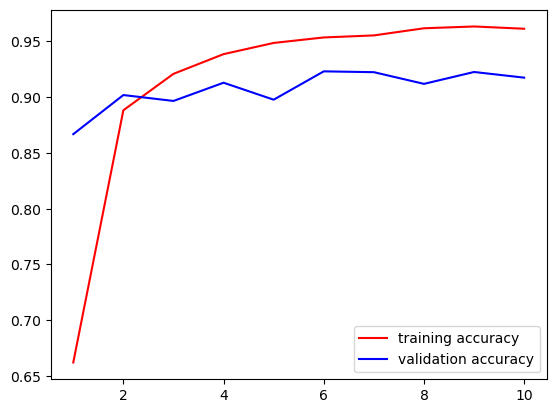

In [30]:
epochs=[ i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='training accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='validation accuracy')
plt.xlabel=("No.of Epochs")
plt.ylabel=("Accuracy Result")
plt.title=("Visulaization of accuracy result")
plt.legend()
plt.show()

## Some other metrics for  Evalution

In [31]:
class_name=validation_set.class_names
class_name


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [32]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    
    
)

Found 17572 files belonging to 38 classes.


In [33]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 267s 485ms/step


(array([[8.9914334e-01, 1.1262419e-03, 1.4883442e-05, ..., 4.9014321e-09,
         1.9258786e-09, 1.6250625e-09],
        [9.9997151e-01, 2.6904712e-10, 2.4972734e-11, ..., 2.8708856e-16,
         7.2210474e-14, 2.9500315e-15],
        [9.9999976e-01, 9.3756491e-10, 2.4775531e-09, ..., 9.5282339e-18,
         9.1028584e-13, 7.6339990e-11],
        ...,
        [1.4975503e-05, 1.9304653e-14, 2.5079789e-06, ..., 7.3889656e-05,
         1.6522857e-10, 8.8718516e-01],
        [1.7744405e-10, 2.7262812e-24, 1.1600679e-13, ..., 1.1611539e-03,
         9.1594809e-13, 9.9654788e-01],
        [1.3107728e-11, 1.4665204e-16, 2.0679941e-13, ..., 2.2170348e-09,
         8.8534907e-10, 9.9870408e-01]], shape=(17572, 38), dtype=float32),
 (17572, 38))

In [34]:
predicted_categories=tf.argmax(y_pred,axis=1)

In [35]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [36]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [37]:
Y_true=tf.argmax(y_pred,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [38]:
from sklearn.metrics import classification_report,confusion_matrix

In [39]:
import tensorflow as tf

model = tf.keras.models.load_model("tarined_model.h5")

In [40]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)
    
    

Found 17572 files belonging to 38 classes.


In [41]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

Y_pred = model.predict(test_set)
predicted_categories = np.argmax(Y_pred, axis=1)

Y_true = np.concatenate([y for x, y in test_set], axis=0)
Y_true = np.argmax(Y_true, axis=1)

class_name = test_set.class_names

print(classification_report(Y_true, predicted_categories, target_names=class_name, zero_division=0))

550/550 ━━━━━━━━━━━━━━━━━━━━ 267s 485ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.93      0.93       504
                                 Apple___Black_rot       0.97      0.97      0.97       497
                          Apple___Cedar_apple_rust       0.94      0.94      0.94       440
                                   Apple___healthy       0.88      0.89      0.89       502
                               Blueberry___healthy       0.96      0.91      0.94       454
          Cherry_(including_sour)___Powdery_mildew       0.96      0.97      0.97       421
                 Cherry_(including_sour)___healthy       0.98      0.96      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.87      0.87       410
                       Corn_(maize)___Common_rust_       0.99      0.98      0.98       477
               Corn_(maize)___Nort

In [42]:
cm=confusion_matrix(Y_true,predicted_categories)
cm.shape

(38, 38)

# #  Confusion matrix visualization


In [46]:
import importlib
import matplotlib.pyplot as plt
importlib.reload(plt)

<module 'matplotlib.pyplot' from 'C:\\Users\\shaiv\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

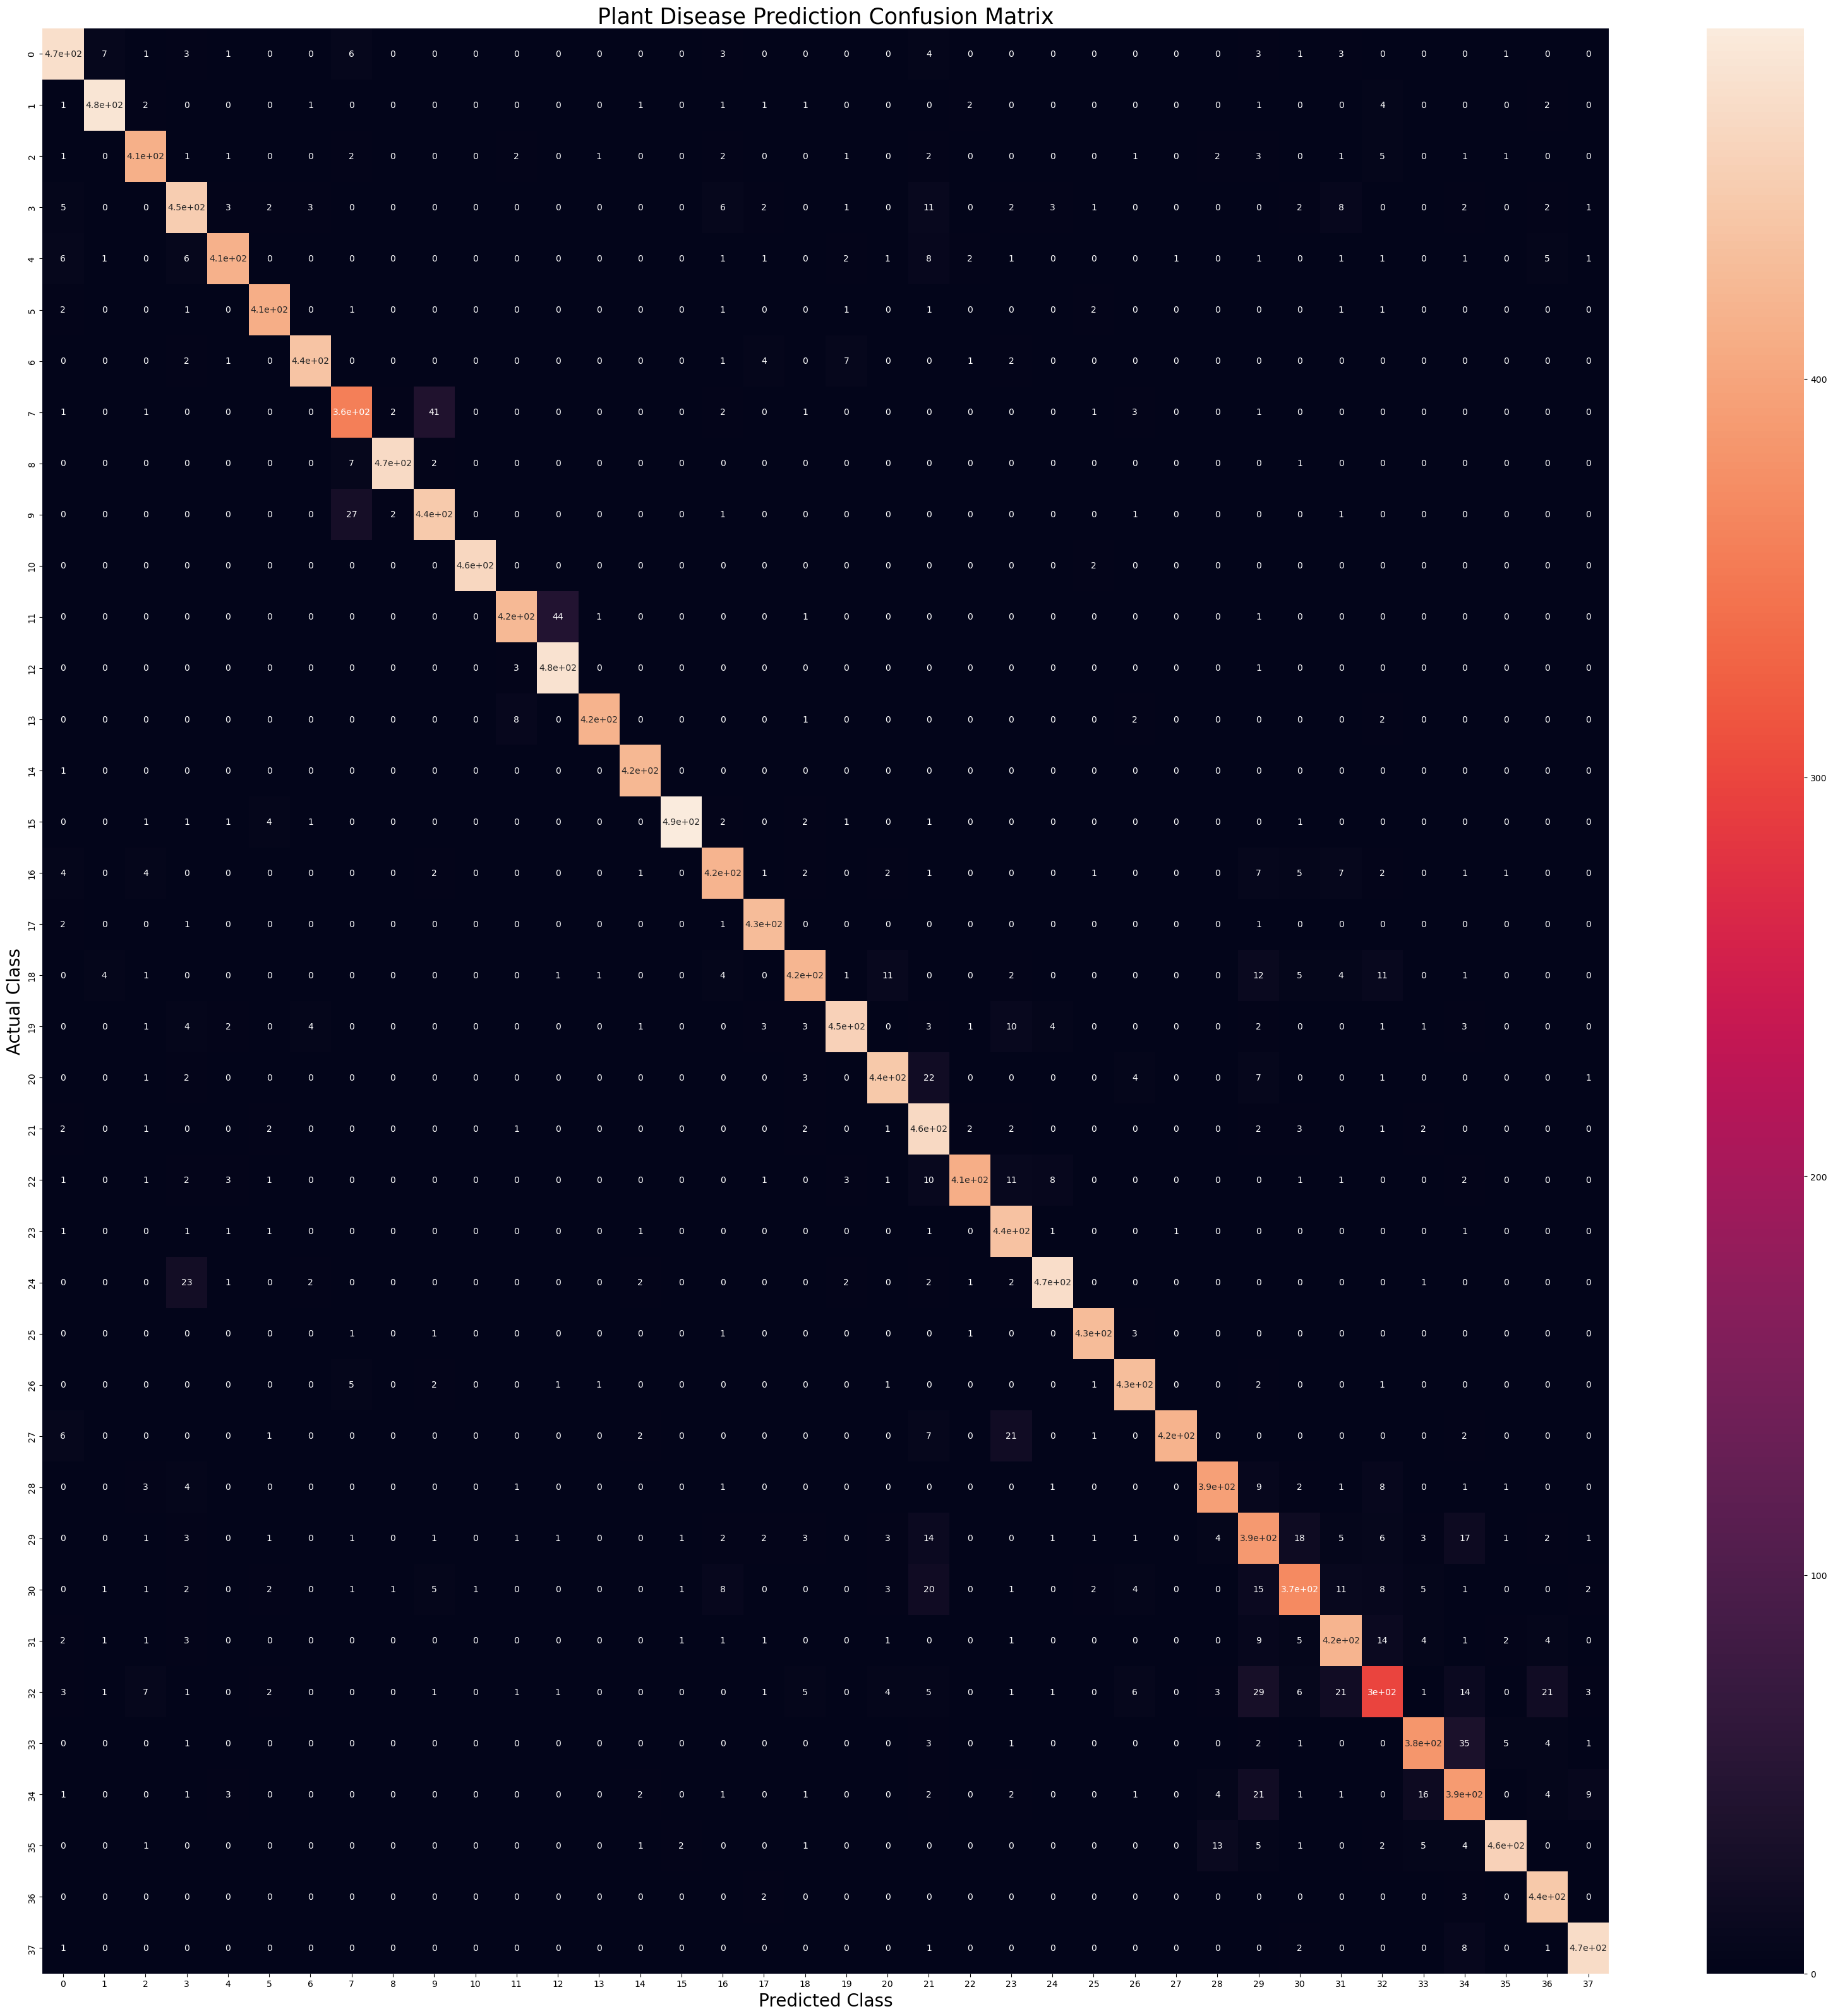

In [47]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()